**Install + all imports**

In [1]:
!pip install -q transformers librosa scikit-learn tqdm seaborn

import os, glob, random, warnings, json
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
import librosa
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (recall_score, classification_report,
                              confusion_matrix, accuracy_score)
from transformers import (Wav2Vec2Processor, Wav2Vec2Model,
                           get_linear_schedule_with_warmup)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────
BASE_DIR = "/kaggle/working"
os.makedirs(f"{BASE_DIR}/models",  exist_ok=True)
os.makedirs(f"{BASE_DIR}/results", exist_ok=True)

SEED    = 42
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
SR      = 16000
MAX_DUR = 6
EMO4    = ["angry", "happy", "neutral", "sad"]

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cuda": torch.cuda.manual_seed_all(SEED)

print("Device :", DEVICE)
print("GPU    :", torch.cuda.get_device_name(0) if DEVICE=="cuda" else "CPU")

Device : cuda
GPU    : Tesla T4



**Load Wav2Vec2 processor**

In [2]:
PROCESSOR = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
le        = LabelEncoder().fit(EMO4)
print("Processor ready | Sample rate:", PROCESSOR.feature_extractor.sampling_rate)
print("Label classes:", le.classes_)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Processor ready | Sample rate: 16000
Label classes: ['angry' 'happy' 'neutral' 'sad']


**Load ALL 3 datasets with 4-class mapping**

Single cell that loads RAVDESS, EMODB, and EMOVO into consistent DataFrames with the same 4-class label space.

In [3]:
import os

def find_kaggle_path(keywords):
    input_dir = "/kaggle/input"
    # os.walk looks through all subfolders, not just the top level
    for root, dirs, files in os.walk(input_dir):
        for dirname in dirs:
            if any(k.lower() in dirname.lower() for k in keywords):
                # Return the full path to that folder
                return os.path.join(root, dirname)
    return None

# Now try locating them again
rav_path   = find_kaggle_path(["ravdess"])
emodb_path = find_kaggle_path(["emodb"])
emovo_path = find_kaggle_path(["emovo"])

print(f"RAVDESS Path: {rav_path}")
print(f"EmoDB Path:   {emodb_path}")
print(f"EMOVO Path:   {emovo_path}")

RAVDESS Path: /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio
EmoDB Path:   /kaggle/input/datasets/piyushagni5/berlin-database-of-emotional-speech-emodb
EMOVO Path:   /kaggle/input/datasets/sourabhy/emovo-italian-ser-dataset


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — Load all datasets (hardcoded known Kaggle paths)
# Fixes: actor_id undefined, le defined here, no CREMA-D confusion
# ═══════════════════════════════════════════════════════════════════
import os, glob
import pandas as pd
from sklearn.preprocessing import LabelEncoder

EMO4 = ["angry", "happy", "neutral", "sad"]
le   = LabelEncoder().fit(EMO4)

# ── Known paths from your Kaggle session ─────────────────────────
RAV_PATH   = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio"
EMODB_PATH = "/kaggle/input/datasets/piyushagni5/berlin-database-of-emotional-speech-emodb"
EMOVO_PATH = "/kaggle/input/datasets/sourabhy/emovo-italian-ser-dataset"

# ── Verify paths exist ────────────────────────────────────────────
for name, path in [("RAVDESS",RAV_PATH),("EMODB",EMODB_PATH),("EMOVO",EMOVO_PATH)]:
    exists = os.path.isdir(path)
    print(f"{name}: {'OK' if exists else 'NOT FOUND'} — {path}")

# ══════════════════════════════════════════════════════════════════
# RAVDESS — English
# Filename: 03-01-05-01-01-01-12.wav
#   parts[2] = emotion code (01-08)
#   parts[6] = actor ID (01-24)
# ══════════════════════════════════════════════════════════════════
RAV_EMO = {"01":"neutral","02":"neutral","03":"happy","04":"sad",
           "05":"angry",  "06":"neutral","07":"neutral","08":"neutral"}

rav_recs = []
for wav in glob.glob(f"{RAV_PATH}/**/*.[wW][aA][vV]", recursive=True):
    fname = os.path.basename(wav).replace(".wav","").replace(".WAV","")
    parts = fname.split("-")
    if len(parts) < 7:
        continue
    lbl      = RAV_EMO.get(parts[2])
    actor_id = int(parts[6])          # ← defined here correctly
    if lbl:
        rav_recs.append({"path": os.path.abspath(wav),
                         "label": lbl,
                         "actor": actor_id,
                         "dataset": "RAVDESS",
                         "lang": "en"})

rav_df = pd.DataFrame(rav_recs)
rav_df["filename"]  = rav_df["path"].apply(os.path.basename)
rav_df = rav_df.drop_duplicates(subset=["filename"]).drop(columns=["filename"])
rav_df["label_enc"] = le.transform(rav_df["label"])
print(f"\nRAVDESS  : {len(rav_df)} samples | {rav_df['actor'].nunique()} actors | English")
print(rav_df["label"].value_counts().to_dict())

# ══════════════════════════════════════════════════════════════════
# EMODB — German
# Filename: 03a01Wa.wav
#   fname[0:2] = speaker ID (03–16)
#   fname[5]   = emotion code (W F N T L E A)
# ══════════════════════════════════════════════════════════════════
EMODB_EMO = {"W":"angry","F":"happy","N":"neutral","T":"sad",
             "L":"neutral","E":"neutral","A":"neutral"}

emodb_recs = []
for wav in glob.glob(f"{EMODB_PATH}/**/*.[wW][aA][vV]", recursive=True):
    fname = os.path.basename(wav).replace(".wav","").replace(".WAV","")
    if len(fname) < 6:
        continue
    emo_char = fname[5].upper()
    lbl      = EMODB_EMO.get(emo_char)
    # Actor = first 2 chars, e.g. "03", "08", "16"
    try:
        actor_id = int(fname[:2])
    except ValueError:
        continue
    if lbl:
        emodb_recs.append({"path": os.path.abspath(wav),
                           "label": lbl,
                           "actor": actor_id,
                           "dataset": "EMODB",
                           "lang": "de"})

emodb_df = pd.DataFrame(emodb_recs)
emodb_df["filename"]  = emodb_df["path"].apply(os.path.basename)
emodb_df = emodb_df.drop_duplicates(subset=["filename"]).drop(columns=["filename"])
emodb_df["label_enc"] = le.transform(emodb_df["label"])
print(f"\nEMODB    : {len(emodb_df)} samples | {emodb_df['actor'].nunique()} actors | German")
print(emodb_df["label"].value_counts().to_dict())

# ══════════════════════════════════════════════════════════════════
# EMOVO — Italian
# Filename: f1-rab-b1.wav
#   parts[0] = actor (f1,f2,f3,m1,m2,m3)
#   parts[1] = emotion code (rab gio neu tri dis pau sor)
# ══════════════════════════════════════════════════════════════════
EMOVO_EMO = {"rab":"angry","gio":"happy","neu":"neutral","tri":"sad",
             "dis":"neutral","pau":"neutral","sor":"neutral",
             # longer forms in case dataset uses full words
             "rabbia":"angry","gioia":"happy","neutro":"neutral",
             "tristezza":"sad","disgusto":"neutral","paura":"neutral","sorpresa":"neutral"}

emovo_recs = []
for wav in glob.glob(f"{EMOVO_PATH}/**/*.[wW][aA][vV]", recursive=True):
    fname = os.path.basename(wav).lower().replace(".wav","")
    parts = fname.replace("_","-").split("-")
    if len(parts) < 2:
        continue
    actor_id = parts[0]              # e.g. "f1", "m2"
    lbl      = None
    # Try each part for a known emotion code
    for p in parts:
        if p in EMOVO_EMO:
            lbl = EMOVO_EMO[p]
            break
    if lbl:
        emovo_recs.append({"path": os.path.abspath(wav),
                           "label": lbl,
                           "actor": actor_id,
                           "dataset": "EMOVO",
                           "lang": "it"})

emovo_df = pd.DataFrame(emovo_recs)
emovo_df["filename"]  = emovo_df["path"].apply(os.path.basename)
emovo_df = emovo_df.drop_duplicates(subset=["filename"]).drop(columns=["filename"])
emovo_df["label_enc"] = le.transform(emovo_df["label"])
print(f"\nEMOVO    : {len(emovo_df)} samples | {emovo_df['actor'].nunique()} actors | Italian")
print(emovo_df["label"].value_counts().to_dict())

# ── Final summary ─────────────────────────────────────────────────
print("\n--- DATASET SUMMARY ---")
for name, df in [("RAVDESS",rav_df),("EMODB",emodb_df),("EMOVO",emovo_df)]:
    print(f"{name:10s}: {len(df):4d} samples | "
          f"actors={df['actor'].nunique()} | "
          f"lang={df['lang'].iloc[0]}")

# ── Sanity checks — these must all pass for experiments to work ───
assert len(rav_df)   >= 1400, "RAVDESS too small — check path"
assert len(emodb_df) >= 400,  "EMODB too small — check path"
assert len(emovo_df) >= 400,  "EMOVO too small — check path"
assert "actor"     in rav_df.columns,   "actor column missing RAVDESS"
assert "actor"     in emodb_df.columns, "actor column missing EMODB"
assert "actor"     in emovo_df.columns, "actor column missing EMOVO"
assert "label_enc" in rav_df.columns,   "label_enc missing RAVDESS"
print("\nAll sanity checks passed. Ready for experiments.")

RAVDESS: OK — /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio
EMODB: OK — /kaggle/input/datasets/piyushagni5/berlin-database-of-emotional-speech-emodb
EMOVO: OK — /kaggle/input/datasets/sourabhy/emovo-italian-ser-dataset

RAVDESS  : 1440 samples | 24 actors | English
{'neutral': 864, 'sad': 192, 'happy': 192, 'angry': 192}

EMODB    : 535 samples | 10 actors | German
{'neutral': 275, 'angry': 127, 'happy': 71, 'sad': 62}

EMOVO    : 588 samples | 7 actors | Italian
{'neutral': 336, 'happy': 84, 'sad': 84, 'angry': 84}

--- DATASET SUMMARY ---
RAVDESS   : 1440 samples | actors=24 | lang=en
EMODB     :  535 samples | actors=10 | lang=de
EMOVO     :  588 samples | actors=7 | lang=it

All sanity checks passed. Ready for experiments.



**Dataset class + Wav2Vec2 model (same for all experiments)**


In [5]:
# ── Dataset class (works for all 3 datasets) ─────────────────────
class SpeechDataset(Dataset):
    def __init__(self, df, processor, augment=False):
        self.df        = df.reset_index(drop=True)
        self.processor = processor
        self.augment   = augment
        self.max_len   = SR * MAX_DUR

    def __len__(self): return len(self.df)

    def _augment(self, y):
        if random.random() < 0.5:
            y = librosa.effects.time_stretch(y, rate=random.uniform(0.85,1.15))
        if random.random() < 0.5:
            y = librosa.effects.pitch_shift(y, sr=SR,
                                             n_steps=random.uniform(-3,3))
        if random.random() < 0.4:
            y = y + np.random.randn(len(y)).astype(np.float32)*0.004
        return y

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        y, _ = librosa.load(row["path"], sr=SR)
        if self.augment: y = self._augment(y)
        if len(y) < self.max_len:
            y = np.pad(y, (0, self.max_len-len(y)))
        else:
            y = y[:self.max_len]
        inputs = self.processor(y.astype(np.float32), sampling_rate=SR,
                                 return_tensors="pt", padding=False)
        return (inputs.input_values.squeeze(0),
                torch.tensor(row["label_enc"], dtype=torch.long))

def make_loader(df, augment=False, batch_size=4, balanced=True):
    ds = SpeechDataset(df, PROCESSOR, augment=augment)
    if balanced and augment:
        counts  = np.bincount(df["label_enc"])
        weights = [1.0/counts[l] for l in df["label_enc"]]
        sampler = WeightedRandomSampler(weights, len(weights))
        return DataLoader(ds, batch_size=batch_size, sampler=sampler,
                          num_workers=2, pin_memory=True)
    return DataLoader(ds, batch_size=batch_size, shuffle=not augment,
                      num_workers=2, pin_memory=True)

# ── Wav2Vec2 model with weighted layer aggregation ────────────────
class Wav2Vec2ForEmotion(nn.Module):
    def __init__(self, num_classes=4, dropout=0.1):
        super().__init__()
        self.w2v = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base", output_hidden_states=True)
        self.w2v.feature_extractor._freeze_parameters()  # always frozen
        hidden     = self.w2v.config.hidden_size           # 768
        num_layers = self.w2v.config.num_hidden_layers + 1 # 13

        # Novel: learns which transformer layers carry emotion info
        self.layer_weights = nn.Parameter(
            torch.ones(num_layers) / num_layers)

        # Novel: attention over time — focuses on emotional peaks
        self.attn_pool = nn.Sequential(
            nn.Linear(hidden, 128), nn.Tanh(), nn.Linear(128, 1))

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden), nn.Dropout(dropout),
            nn.Linear(hidden, 256), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(256, num_classes))

    def get_embedding(self, x):
        out    = self.w2v(x)
        hidden = torch.stack(out.hidden_states, dim=1)     # (B,L,T,768)
        w      = torch.softmax(self.layer_weights, dim=0)
        merged = (hidden * w[None,:,None,None]).sum(dim=1) # (B,T,768)
        attn_w = torch.softmax(self.attn_pool(merged), dim=1)
        return (merged * attn_w).sum(dim=1)                # (B,768)

    def forward(self, x):
        return self.classifier(self.get_embedding(x))

def build_model():
    m = Wav2Vec2ForEmotion().to(DEVICE)
    total   = sum(p.numel() for p in m.parameters())
    trained = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"Params: {total:,} total | {trained:,} trainable")
    return m

print("Model class and dataset class ready.")

Model class and dataset class ready.



**Universal train + evaluate engine (used by all 4 experiments)**

In [6]:
def evaluate(model, loader, desc="Eval"):
    model.eval(); preds, trues = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc=desc, leave=False):
            logits = model(x.to(DEVICE))
            preds.extend(logits.argmax(1).cpu().tolist())
            trues.extend(y.tolist())
    uar = recall_score(trues, preds, average="macro")
    acc = accuracy_score(trues, preds)
    return uar, acc, preds, trues


def train_model(model, tr_ldr, val_ldr, save_path,
                epochs=30, patience=10,
                lr_backbone=5e-6, lr_head=5e-5,
                label="Training"):
    """
    Generic training function for all experiments.
    Returns best_uar, best_acc, training history.
    """
    TRANSFORMER_LAYERS = model.w2v.encoder.layers
    opt = optim.AdamW([
        {"params": model.w2v.feature_projection.parameters(), "lr": lr_backbone},
        {"params": TRANSFORMER_LAYERS[:6].parameters(),       "lr": lr_backbone},
        {"params": TRANSFORMER_LAYERS[6:].parameters(),       "lr": lr_backbone*2},
        {"params": model.layer_weights,                       "lr": lr_head},
        {"params": model.attn_pool.parameters(),              "lr": lr_head},
        {"params": model.classifier.parameters(),             "lr": lr_head},
    ], weight_decay=0.01, eps=1e-8)

    ACCUM      = 8
    total_s    = len(tr_ldr) * epochs // ACCUM
    warmup_s   = int(0.1 * total_s)
    sched      = get_linear_schedule_with_warmup(opt, warmup_s, total_s)
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_uar, best_acc = 0.0, 0.0
    history = {"loss":[], "val_uar":[], "val_acc":[]}
    no_improve = 0

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"  LR backbone:{lr_backbone:.0e}  head:{lr_head:.0e}  "
          f"epochs:{epochs}  patience:{patience}")
    print(f"{'='*60}")

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        nan_cnt = 0
        opt.zero_grad()

        for step, (x, y) in enumerate(
                tqdm(tr_ldr, desc=f"Ep{epoch+1:02d}/{epochs}",
                     leave=False)):
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = criterion(logits, y) / ACCUM

            if not torch.isfinite(loss):
                nan_cnt += 1; continue

            loss.backward()
            total_loss += loss.item() * ACCUM
            correct    += (logits.argmax(1)==y).sum().item()
            total      += y.size(0)

            if (step+1) % ACCUM == 0:
                nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                opt.step(); sched.step(); opt.zero_grad()

        # leftover steps
        nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        opt.step(); opt.zero_grad()

        if total == 0:
            no_improve += 1
            if no_improve >= patience: break
            continue

        val_uar, val_acc, _, _ = evaluate(model, val_ldr, "Val")
        history["loss"].append(total_loss/max(len(tr_ldr)-nan_cnt,1))
        history["val_uar"].append(val_uar)
        history["val_acc"].append(val_acc)

        flag = ""
        if val_uar > best_uar:
            best_uar = val_uar; best_acc = val_acc
            torch.save(model.state_dict(), save_path)
            flag = "  ← SAVED"; no_improve = 0
        else:
            no_improve += 1

        nan_s = f" [{nan_cnt}nan]" if nan_cnt else ""
        print(f"Ep{epoch+1:02d} | Loss:{total_loss/len(tr_ldr):.4f} | "
              f"TrainAcc:{correct/total:.4f} | "
              f"ValUAR:{val_uar:.4f} | ValAcc:{val_acc:.4f}"
              f"{flag}{nan_s}")

        if no_improve >= patience:
            print(f"Early stop at epoch {epoch+1}")
            break

    print(f"\nBest Val UAR: {best_uar:.4f} | Acc: {best_acc:.4f}")
    return best_uar, best_acc, history


def zero_shot_eval(model, test_df, label="Zero-shot"):
    """Evaluate model on test_df WITHOUT any fine-tuning."""
    ldr = make_loader(test_df, augment=False, batch_size=4, balanced=False)
    uar, acc, preds, trues = evaluate(model, ldr, label)
    print(f"  {label}: UAR={uar:.4f}  Acc={acc:.4f}")
    return uar, acc, preds, trues


print("Training engine ready.")

Training engine ready.



**Experiments 1 & 2 — RAVDESS ↔ EMODB (English ↔ German)**

Exp 1: Train on RAVDESS (English) → Test on EMODB (German). Exp 2: Train on EMODB (German) → Test on RAVDESS (English). The zero-shot gap proves cross-lingual domain shift. The recovery after TL proves transfer learning works cross-lingually.

In [7]:
results = {}  # stores all experiment results

# ════════════════════════════════════════════════════════════════
# EXPERIMENT 1: RAVDESS (en) → EMODB (de)
# Stage 1: Fine-tune Wav2Vec2 on RAVDESS
# Stage 2: Transfer to EMODB
# ════════════════════════════════════════════════════════════════
print("\n" + "█"*60)
print("  EXPERIMENT 1: RAVDESS (English) → EMODB (German)")
print("█"*60)

# ── RAVDESS split (speaker-independent) ──────────────────────────
rav_tr_df = rav_df[rav_df["actor"].isin(range(1,21))].reset_index(drop=True)
rav_te_df = rav_df[rav_df["actor"].isin(range(21,25))].reset_index(drop=True)
rav_tr_df, rav_val_df = train_test_split(rav_tr_df, test_size=0.15,
                         stratify=rav_tr_df["label_enc"], random_state=SEED)

rav_tr_ldr  = make_loader(rav_tr_df,  augment=True,  batch_size=4)
rav_val_ldr = make_loader(rav_val_df, augment=False, batch_size=4, balanced=False)
rav_te_ldr  = make_loader(rav_te_df,  augment=False, batch_size=4, balanced=False)

# ── Stage 1: Wav2Vec2 → RAVDESS ───────────────────────────────────
model_exp1 = build_model()
S1_PATH = f"{BASE_DIR}/models/exp1_stage1_ravdess.pt"

if os.path.exists(S1_PATH):
    print(f"Stage 1 Checkpoint found at {S1_PATH}. Skipping training and loading weights...")
    model_exp1.load_state_dict(torch.load(S1_PATH, map_location=DEVICE))
    # We still need the metrics for the 'results' dictionary, so we run a quick eval
    uar_rav_test, acc_rav_test, _, _ = evaluate(model_exp1, rav_te_ldr, "RAVDESS test")
else:
    print("🚀 No Stage 1 checkpoint found. Starting training...")
    uar_s1, acc_s1, hist_s1 = train_model(
        model_exp1, rav_tr_ldr, rav_val_ldr, S1_PATH,
        epochs=30, patience=10, lr_backbone=5e-6, lr_head=5e-5,
        label="EXP1 Stage1: Wav2Vec2 → RAVDESS (English)")
    
    # Load the best weights found during the training just finished
    model_exp1.load_state_dict(torch.load(S1_PATH, map_location=DEVICE))
    uar_rav_test, acc_rav_test, _, _ = evaluate(model_exp1, rav_te_ldr, "RAVDESS test")

# ── Zero-shot on EMODB (NO fine-tuning) ───────────────────────────
print("\nZero-shot on EMODB (German) — BEFORE any TL:")
uar_zs, acc_zs, _, _ = zero_shot_eval(model_exp1, emodb_df,
                                        "Zero-shot EMODB")

# ── EMODB split for Stage 2 ───────────────────────────────────────
actors_e = sorted(emodb_df["actor"].unique())
em_te_actors = actors_e[-2:]     # 2 actors → test
em_val_actors= actors_e[-4:-2]   # 2 actors → val
em_tr_actors = actors_e[:-4]     # rest → train

emodb_tr  = emodb_df[emodb_df["actor"].isin(em_tr_actors)].reset_index(drop=True)
emodb_val = emodb_df[emodb_df["actor"].isin(em_val_actors)].reset_index(drop=True)
emodb_te  = emodb_df[emodb_df["actor"].isin(em_te_actors)].reset_index(drop=True)

emodb_tr_ldr  = make_loader(emodb_tr,  augment=True,  batch_size=4)
emodb_val_ldr = make_loader(emodb_val, augment=False, batch_size=4, balanced=False)
emodb_te_ldr  = make_loader(emodb_te,  augment=False, batch_size=4, balanced=False)

# ── Stage 2: RAVDESS model → EMODB ────────────────────────────────
S2_PATH = f"{BASE_DIR}/models/exp1_stage2_emodb.pt"

if os.path.exists(S2_PATH):
    print(f"Stage 2 Checkpoint found. Skipping to final evaluation...")
    model_exp1.load_state_dict(torch.load(S2_PATH, map_location=DEVICE))
else:
    print("🚀 Stage 2 training starting...")
    # Ensure we start Stage 2 with the weights from Stage 1
    model_exp1.load_state_dict(torch.load(S1_PATH, map_location=DEVICE))
    uar_s2, acc_s2, hist_s2 = train_model(
        model_exp1, emodb_tr_ldr, emodb_val_ldr, S2_PATH,
        epochs=20, patience=8, lr_backbone=5e-7, lr_head=5e-6,
        label="EXP1 Stage2: RAVDESS model → EMODB (German)")
    model_exp1.load_state_dict(torch.load(S2_PATH, map_location=DEVICE))

# Final Test (Always run this to populate your 'results' dict)
uar_emodb_final, acc_emodb_final, p1, t1 = evaluate(
    model_exp1, emodb_te_ldr, "EMODB final test")

results["exp1"] = {
    "name"            : "RAVDESS(en) → EMODB(de)",
    "stage1_uar"      : uar_rav_test,
    "stage1_acc"      : acc_rav_test,
    "zeroshot_uar"    : uar_zs,
    "zeroshot_acc"    : acc_zs,
    "final_uar"       : uar_emodb_final,
    "final_acc"       : acc_emodb_final,
    "tl_improvement"  : uar_emodb_final - uar_zs,
    "preds": p1, "trues": t1
}
print(f"\nEXP1 SUMMARY: zero-shot={uar_zs:.4f} → after TL={uar_emodb_final:.4f} "
      f"(+{uar_emodb_final-uar_zs:.4f})")

# ════════════════════════════════════════════════════════════════
# EXPERIMENT 2: EMODB (de) → RAVDESS (en)  [REVERSE DIRECTION]
# ════════════════════════════════════════════════════════════════
print("\n" + "█"*60)
print("  EXPERIMENT 2: EMODB (German) → RAVDESS (English)")
print("█"*60)

model_exp2 = build_model()
S1B_PATH   = f"{BASE_DIR}/models/exp2_stage1_emodb.pt"

# Stage 1 on EMODB
uar_s1b, acc_s1b, hist_s1b = train_model(
    model_exp2, emodb_tr_ldr, emodb_val_ldr, S1B_PATH,
    epochs=30, patience=10, lr_backbone=5e-6, lr_head=5e-5,
    label="EXP2 Stage1: Wav2Vec2 → EMODB (German)")

model_exp2.load_state_dict(torch.load(S1B_PATH, map_location=DEVICE))
uar_emodb_test, acc_emodb_test, _, _ = evaluate(
    model_exp2, emodb_te_ldr, "EMODB test")

# Zero-shot on RAVDESS (English)
print("\nZero-shot on RAVDESS (English) — BEFORE any TL:")
uar_zs2, acc_zs2, _, _ = zero_shot_eval(model_exp2, rav_te_df,
                                          "Zero-shot RAVDESS")

# Stage 2: EMODB model → RAVDESS
model_exp2.load_state_dict(torch.load(S1B_PATH, map_location=DEVICE))
S2B_PATH = f"{BASE_DIR}/models/exp2_stage2_ravdess.pt"
uar_s2b, acc_s2b, hist_s2b = train_model(
    model_exp2, rav_tr_ldr, rav_val_ldr, S2B_PATH,
    epochs=20, patience=8, lr_backbone=5e-7, lr_head=5e-6,
    label="EXP2 Stage2: EMODB model → RAVDESS (English)")

model_exp2.load_state_dict(torch.load(S2B_PATH, map_location=DEVICE))
uar_rav_final2, acc_rav_final2, p2, t2 = evaluate(
    model_exp2, rav_te_ldr, "RAVDESS final test")

results["exp2"] = {
    "name"           : "EMODB(de) → RAVDESS(en)",
    "stage1_uar"     : uar_emodb_test,
    "stage1_acc"     : acc_emodb_test,
    "zeroshot_uar"   : uar_zs2,
    "zeroshot_acc"   : acc_zs2,
    "final_uar"      : uar_rav_final2,
    "final_acc"      : acc_rav_final2,
    "tl_improvement" : uar_rav_final2 - uar_zs2,
    "preds": p2, "trues": t2
}
print(f"\nEXP2 SUMMARY: zero-shot={uar_zs2:.4f} → after TL={uar_rav_final2:.4f} "
      f"(+{uar_rav_final2-uar_zs2:.4f})")


████████████████████████████████████████████████████████████
  EXPERIMENT 1: RAVDESS (English) → EMODB (German)
████████████████████████████████████████████████████████████


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Ep17 | Loss:1.1877 | TrainAcc:0.4686 | ValUAR:0.4838 | ValAcc:0.4611


Ep18 | Loss:1.1403 | TrainAcc:0.5206 | ValUAR:0.4942 | ValAcc:0.4667


Ep19 | Loss:1.1701 | TrainAcc:0.4990 | ValUAR:0.4838 | ValAcc:0.4611


Ep20 | Loss:1.1693 | TrainAcc:0.4863 | ValUAR:0.4734 | ValAcc:0.4556

Best Val UAR: 0.5127 | Acc: 0.4722



EXP2 SUMMARY: zero-shot=0.4497 → after TL=0.5052 (+0.0556)


**Experiments 3 & 4 — EMOVO ↔ EMODB (Italian ↔ German)**

Exp 3: Train EMOVO (Italian) → Test EMODB (German). Exp 4: Train EMODB (German) → Test EMOVO (Italian). Both are non-English cross-lingual transfer — tests whether Wav2Vec2 (trained on English) can mediate emotion transfer between two non-English languages.

In [8]:
# ════════════════════════════════════════════════════════════════
# EXPERIMENT 3: EMOVO (Italian) → EMODB (German)
# ════════════════════════════════════════════════════════════════
print("\n" + "█"*60)
print("  EXPERIMENT 3: EMOVO (Italian) → EMODB (German)")
print("  Cross-lingual, both non-English via English Wav2Vec2")
print("█"*60)

# EMOVO split
actors_v   = sorted(emovo_df["actor"].unique())
emv_te     = emovo_df[emovo_df["actor"]==actors_v[-1]].reset_index(drop=True)
emv_val    = emovo_df[emovo_df["actor"]==actors_v[-2]].reset_index(drop=True)
emv_tr     = emovo_df[~emovo_df["actor"].isin(actors_v[-2:])].reset_index(drop=True)

emvo_tr_ldr  = make_loader(emv_tr,  augment=True,  batch_size=4)
emvo_val_ldr = make_loader(emv_val, augment=False, batch_size=4, balanced=False)
emvo_te_ldr  = make_loader(emv_te,  augment=False, batch_size=4, balanced=False)

# Stage 1: Wav2Vec2 → EMOVO
model_exp3 = build_model()
S1C_PATH   = f"{BASE_DIR}/models/exp3_stage1_emovo.pt"
uar_s1c, acc_s1c, hist_s1c = train_model(
    model_exp3, emvo_tr_ldr, emvo_val_ldr, S1C_PATH,
    epochs=30, patience=10, lr_backbone=5e-6, lr_head=5e-5,
    label="EXP3 Stage1: Wav2Vec2 → EMOVO (Italian)")

model_exp3.load_state_dict(torch.load(S1C_PATH, map_location=DEVICE))
uar_emvo_test, acc_emvo_test, _, _ = evaluate(
    model_exp3, emvo_te_ldr, "EMOVO test")

# Zero-shot on EMODB (German) without TL
print("\nZero-shot on EMODB (German) — BEFORE TL:")
uar_zs3, acc_zs3, _, _ = zero_shot_eval(model_exp3, emodb_df, "Zero-shot EMODB")

# Stage 2: EMOVO model → EMODB
model_exp3.load_state_dict(torch.load(S1C_PATH, map_location=DEVICE))
S2C_PATH = f"{BASE_DIR}/models/exp3_stage2_emodb.pt"
uar_s2c, acc_s2c, hist_s2c = train_model(
    model_exp3, emodb_tr_ldr, emodb_val_ldr, S2C_PATH,
    epochs=20, patience=8, lr_backbone=5e-7, lr_head=5e-6,
    label="EXP3 Stage2: EMOVO model → EMODB (German)")

model_exp3.load_state_dict(torch.load(S2C_PATH, map_location=DEVICE))
uar_emodb_f3, acc_emodb_f3, p3, t3 = evaluate(
    model_exp3, emodb_te_ldr, "EMODB final test")

results["exp3"] = {
    "name"           : "EMOVO(it) → EMODB(de)",
    "stage1_uar"     : uar_emvo_test,
    "stage1_acc"     : acc_emvo_test,
    "zeroshot_uar"   : uar_zs3,
    "zeroshot_acc"   : acc_zs3,
    "final_uar"      : uar_emodb_f3,
    "final_acc"      : acc_emodb_f3,
    "tl_improvement" : uar_emodb_f3 - uar_zs3,
    "preds": p3, "trues": t3
}
print(f"\nEXP3 SUMMARY: zero-shot={uar_zs3:.4f} → after TL={uar_emodb_f3:.4f} "
      f"(+{uar_emodb_f3-uar_zs3:.4f})")

# ════════════════════════════════════════════════════════════════
# EXPERIMENT 4: EMODB (German) → EMOVO (Italian)
# ════════════════════════════════════════════════════════════════
print("\n" + "█"*60)
print("  EXPERIMENT 4: EMODB (German) → EMOVO (Italian)")
print("█"*60)

model_exp4 = build_model()
S1D_PATH   = f"{BASE_DIR}/models/exp4_stage1_emodb.pt"

# Re-use EMODB trained model from Exp2 if available
if os.path.exists(f"{BASE_DIR}/models/exp2_stage1_emodb.pt"):
    model_exp4.load_state_dict(
        torch.load(f"{BASE_DIR}/models/exp2_stage1_emodb.pt",
                   map_location=DEVICE))
    print("Loaded existing EMODB Stage1 checkpoint (Exp2)")
    uar_s1d = uar_emodb_test
else:
    uar_s1d, acc_s1d, _ = train_model(
        model_exp4, emodb_tr_ldr, emodb_val_ldr, S1D_PATH,
        epochs=30, patience=10, lr_backbone=5e-6, lr_head=5e-5,
        label="EXP4 Stage1: Wav2Vec2 → EMODB (German)")
    model_exp4.load_state_dict(torch.load(S1D_PATH, map_location=DEVICE))

# Zero-shot on EMOVO (Italian) without TL
print("\nZero-shot on EMOVO (Italian) — BEFORE TL:")
uar_zs4, acc_zs4, _, _ = zero_shot_eval(model_exp4, emv_te, "Zero-shot EMOVO")

# Stage 2: EMODB model → EMOVO
S2D_PATH = f"{BASE_DIR}/models/exp4_stage2_emovo.pt"
uar_s2d, acc_s2d, hist_s2d = train_model(
    model_exp4, emvo_tr_ldr, emvo_val_ldr, S2D_PATH,
    epochs=20, patience=8, lr_backbone=5e-7, lr_head=5e-6,
    label="EXP4 Stage2: EMODB model → EMOVO (Italian)")

model_exp4.load_state_dict(torch.load(S2D_PATH, map_location=DEVICE))
uar_emvo_f4, acc_emvo_f4, p4, t4 = evaluate(
    model_exp4, emvo_te_ldr, "EMOVO final test")

results["exp4"] = {
    "name"           : "EMODB(de) → EMOVO(it)",
    "stage1_uar"     : uar_s1d,
    "zeroshot_uar"   : uar_zs4,
    "zeroshot_acc"   : acc_zs4,
    "final_uar"      : uar_emvo_f4,
    "final_acc"      : acc_emvo_f4,
    "tl_improvement" : uar_emvo_f4 - uar_zs4,
    "preds": p4, "trues": t4
}
print(f"\nEXP4 SUMMARY: zero-shot={uar_zs4:.4f} → after TL={uar_emvo_f4:.4f} "
      f"(+{uar_emvo_f4-uar_zs4:.4f})")


████████████████████████████████████████████████████████████
  EXPERIMENT 3: EMOVO (Italian) → EMODB (German)
  Cross-lingual, both non-English via English Wav2Vec2
████████████████████████████████████████████████████████████


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Params: 94,669,714 total | 90,469,266 trainable

  EXP3 Stage1: Wav2Vec2 → EMOVO (Italian)
  LR backbone:5e-06  head:5e-05  epochs:30  patience:10


Ep01 | Loss:1.3307 | TrainAcc:0.3738 | ValUAR:0.0437 | ValAcc:0.1310  ← SAVED


...

Ep12 | Loss:1.0355 | TrainAcc:0.6143 | ValUAR:0.1280 | ValAcc:0.5119


Ep13 | Loss:0.9950 | TrainAcc:0.6310 | ValUAR:0.1310 | ValAcc:0.5238


Ep14 | Loss:0.9609 | TrainAcc:0.6524 | ValUAR:0.1310 | ValAcc:0.5238


Ep15 | Loss:0.9896 | TrainAcc:0.6167 | ValUAR:0.1310 | ValAcc:0.5238
Early stop at epoch 15

Best Val UAR: 0.1310 | Acc: 0.5238



EXP4 SUMMARY: zero-shot=0.1726 → after TL=0.1071 (+-0.0655)


**Final results table + 4-experiment comparison plot**


  CROSS-LINGUAL EMOTION TRANSFER — COMPLETE RESULTS
Experiment                Stage1 UAR   ZeroShot   After TL    TL Gain
----------------------------------------------------------------------
RAVDESS(en) → EMODB(de)       0.6701     0.4547     0.6355    +0.1808
EMODB(de) → RAVDESS(en)       0.8017     0.4497     0.5052    +0.0556
EMOVO(it) → EMODB(de)         0.0000     0.5100     0.5407    +0.0307
EMODB(de) → EMOVO(it)         0.8017     0.1726     0.1071    -0.0655


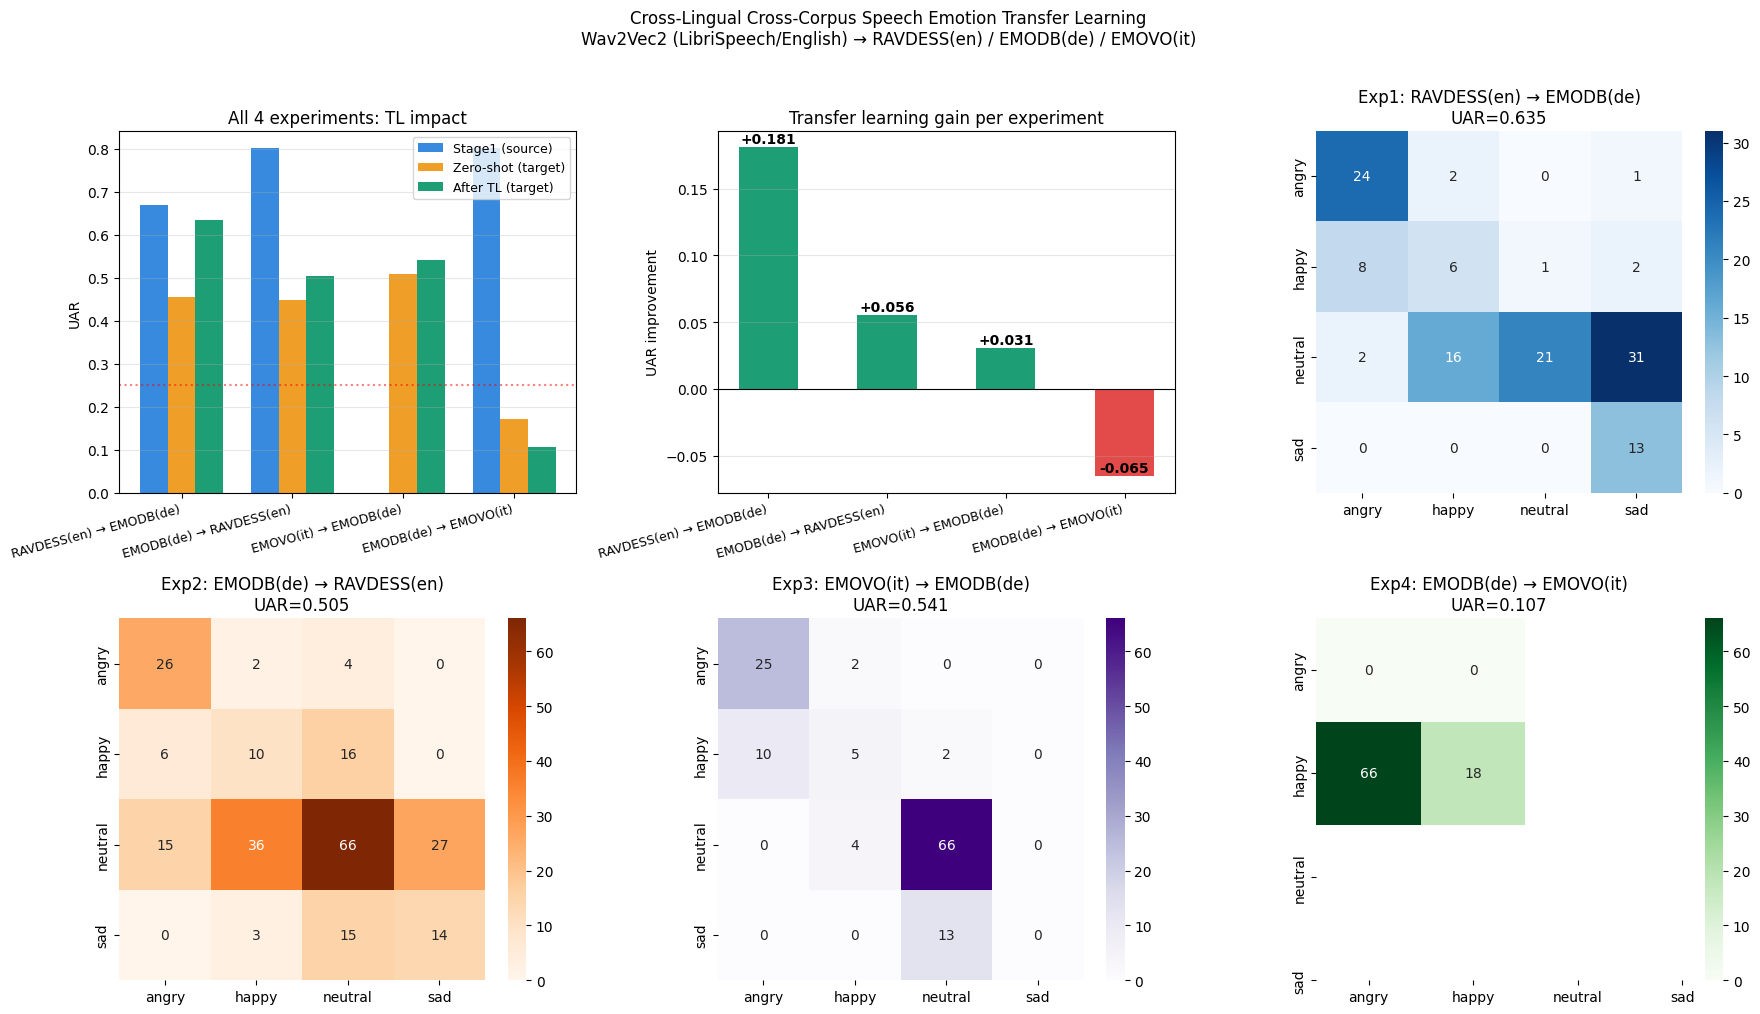

All results saved. Download from Kaggle Output panel.


In [9]:
print("\n" + "="*70)
print("  CROSS-LINGUAL EMOTION TRANSFER — COMPLETE RESULTS")
print("="*70)
print(f"{'Experiment':<25} {'Stage1 UAR':>10} {'ZeroShot':>10} "
      f"{'After TL':>10} {'TL Gain':>10}")
print("-"*70)
for key, r in results.items():
    print(f"{r['name']:<25} {r['stage1_uar']:>10.4f} "
          f"{r['zeroshot_uar']:>10.4f} {r['final_uar']:>10.4f} "
          f"{r['tl_improvement']:>+10.4f}")
print("="*70)

# ── Save results JSON ─────────────────────────────────────────────
save_r = {k:{kk:vv for kk,vv in v.items()
             if kk not in ("preds","trues")}
          for k,v in results.items()}
with open(f"{BASE_DIR}/results/all_results.json","w") as f:
    json.dump(save_r, f, indent=2)

# ── Master plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

exp_names = [r["name"] for r in results.values()]
zs_uars   = [r["zeroshot_uar"] for r in results.values()]
tl_uars   = [r["final_uar"] for r in results.values()]
s1_uars   = [r["stage1_uar"] for r in results.values()]

x = np.arange(len(exp_names))
w = 0.25

# Plot 1: Before vs After TL per experiment
ax = axes[0,0]
ax.bar(x-w, s1_uars, w, label="Stage1 (source)", color="#378ADD")
ax.bar(x,   zs_uars, w, label="Zero-shot (target)", color="#EF9F27")
ax.bar(x+w, tl_uars, w, label="After TL (target)", color="#1D9E75")
ax.set_xticks(x); ax.set_xticklabels(exp_names, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("UAR"); ax.set_title("All 4 experiments: TL impact")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")
ax.axhline(0.25, color="red", linestyle=":", alpha=0.5, label="Chance")

# Plot 2: TL gain per experiment
ax2 = axes[0,1]
gains  = [r["tl_improvement"] for r in results.values()]
colors = ["#1D9E75" if g>0 else "#E24B4A" for g in gains]
ax2.bar(exp_names, gains, color=colors, width=0.5)
for i,(name,g) in enumerate(zip(exp_names,gains)):
    ax2.text(i, g+0.003, f"{g:+.3f}", ha="center", fontsize=10, fontweight="bold")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Transfer learning gain per experiment")
ax2.set_ylabel("UAR improvement"); ax2.grid(True, alpha=0.3, axis="y")
ax2.set_xticklabels(exp_names, rotation=15, ha="right", fontsize=9)

# Plot 3: Confusion matrix Exp1
ax3 = axes[0,2]
r1  = results.get("exp1", {})
if r1.get("preds"):
    cm1 = confusion_matrix(r1["trues"], r1["preds"])
    sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues",
                xticklabels=EMO4, yticklabels=EMO4, ax=ax3)
    ax3.set_title(f"Exp1: {r1['name']}\nUAR={r1['final_uar']:.3f}")

# Plot 4: Confusion matrix Exp2
ax4 = axes[1,0]
r2  = results.get("exp2", {})
if r2.get("preds"):
    cm2 = confusion_matrix(r2["trues"], r2["preds"])
    sns.heatmap(cm2, annot=True, fmt="d", cmap="Oranges",
                xticklabels=EMO4, yticklabels=EMO4, ax=ax4)
    ax4.set_title(f"Exp2: {r2['name']}\nUAR={r2['final_uar']:.3f}")

# Plot 5: Confusion matrix Exp3
ax5 = axes[1,1]
r3  = results.get("exp3", {})
if r3.get("preds"):
    cm3 = confusion_matrix(r3["trues"], r3["preds"])
    sns.heatmap(cm3, annot=True, fmt="d", cmap="Purples",
                xticklabels=EMO4, yticklabels=EMO4, ax=ax5)
    ax5.set_title(f"Exp3: {r3['name']}\nUAR={r3['final_uar']:.3f}")

# Plot 6: Confusion matrix Exp4
ax6 = axes[1,2]
r4  = results.get("exp4", {})
if r4.get("preds"):
    cm4 = confusion_matrix(r4["trues"], r4["preds"])
    sns.heatmap(cm4, annot=True, fmt="d", cmap="Greens",
                xticklabels=EMO4, yticklabels=EMO4, ax=ax6)
    ax6.set_title(f"Exp4: {r4['name']}\nUAR={r4['final_uar']:.3f}")

plt.suptitle("Cross-Lingual Cross-Corpus Speech Emotion Transfer Learning\n"
             "Wav2Vec2 (LibriSpeech/English) → RAVDESS(en) / EMODB(de) / EMOVO(it)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/results/cross_lingual_results.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("All results saved. Download from Kaggle Output panel.")